# Spatial Domain Filtering Lab

Based on the Kathmandu University AICL 311 Image Processing Lab Manual.


## Setup
Import required libraries and load a grayscale image named `image.png`.

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import convolve, gaussian_filter
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

img = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)
img = img.astype(np.float64) / 255.0

np.random.seed(42)
noise_sigma = 0.05
noisy = img + np.random.normal(0, noise_sigma, img.shape)
noisy = np.clip(noisy, 0, 1)


# Experiment 1: Spatial Smoothing Filters

In [3]:
def box_filter(image, kernel_size):
    kernel = np.ones((kernel_size, kernel_size), dtype=np.float64)/(kernel_size*kernel_size)
    return convolve(image, kernel, mode='reflect')

sizes = [3, 7, 15]
results_box = [box_filter(noisy, k) for k in sizes]


In [4]:
sigmas = [0.5, 1.5, 3.0]
results_gauss = [gaussian_filter(noisy, sigma=s, mode='reflect') for s in sigmas]


In [5]:
print('Method'.ljust(20), 'PSNR (dB)'.ljust(15), 'SSIM')
print('-'*45)
for k, r in zip(sizes, results_box):
    print(f'Box k={k}'.ljust(20), f'{psnr(img,r,data_range=1.0):.2f}'.ljust(15), f'{ssim(img,r,data_range=1.0):.4f}')

for s, r in zip(sigmas, results_gauss):
    print(f'Gaussian s={s}'.ljust(20), f'{psnr(img,r,data_range=1.0):.2f}'.ljust(15), f'{ssim(img,r,data_range=1.0):.4f}')


Method               PSNR (dB)       SSIM
---------------------------------------------
Box k=3              30.15           0.8253
Box k=7              24.66           0.8810
Box k=15             20.97           0.8114
Gaussian s=0.5       29.51           0.5974
Gaussian s=1.5       27.38           0.9038
Gaussian s=3.0       23.31           0.8705


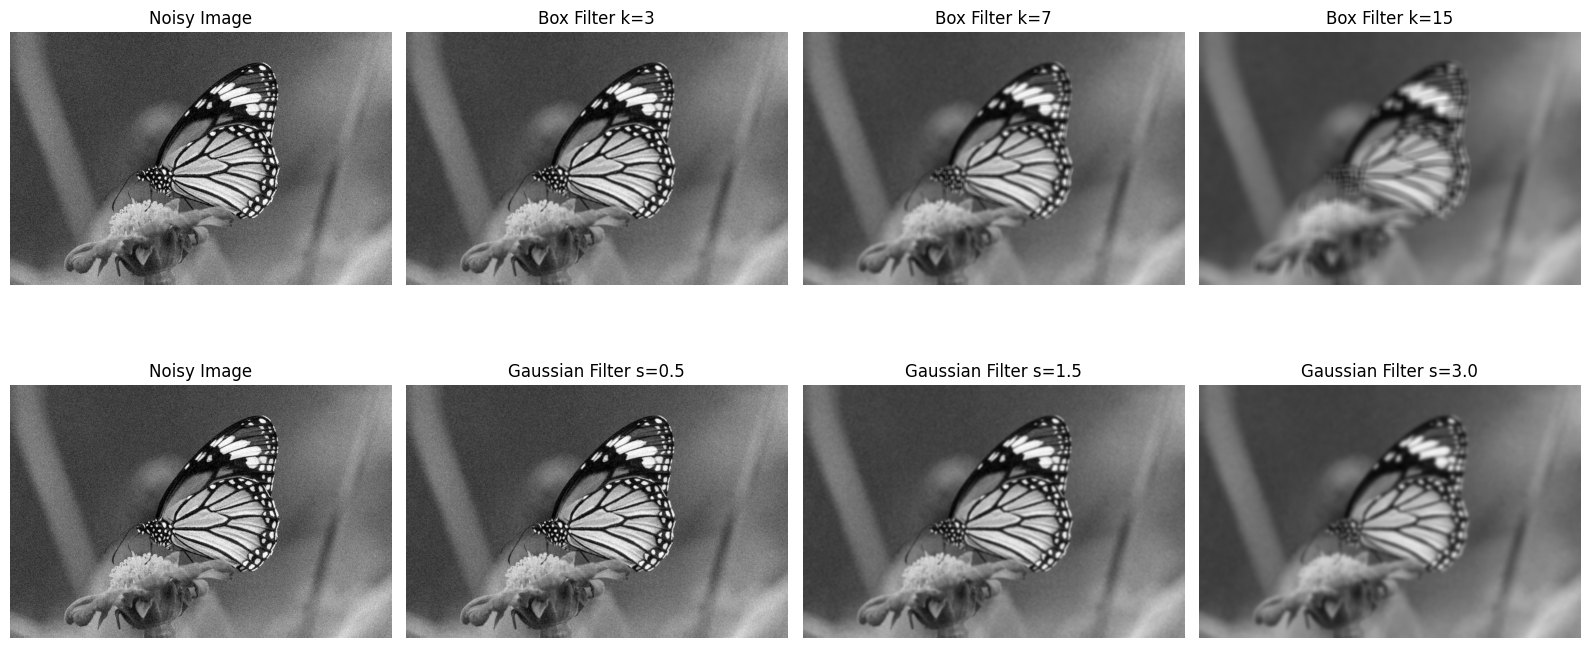

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes[0, 0].imshow(noisy, cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title('Noisy Image')
axes[0, 0].axis('off')
for i, (k, r) in enumerate(zip(sizes, results_box)):
    axes[0, i+1].imshow(r, cmap='gray', vmin=0, vmax=1)
    axes[0, i+1].set_title(f'Box Filter k={k}')
    axes[0, i+1].axis('off')
axes[1, 0].imshow(noisy, cmap='gray', vmin=0, vmax=1)
axes[1, 0].set_title('Noisy Image')
axes[1, 0].axis('off')
for i, (s, r) in enumerate(zip(sigmas, results_gauss)):
    axes[1, i+1].imshow(r, cmap='gray', vmin=0, vmax=1)
    axes[1, i+1].set_title(f'Gaussian Filter s={s}')
    axes[1, i+1].axis('off')
plt.tight_layout()
plt.show()


- **The Plots:** The noisy original image is compared to the outputs of the Box (Mean) filter and the Gaussian filter at increasing strengths (kernel size $k$ for Box, and standard deviation $\sigma$ for Gaussian).
- **The Explanation:** 
  - The **Box filter** applies an equal weight to all neighboring pixels. While it reduces noise, as $k$ gets larger (like $k=7$ or $15$), straight edges start looking like ramp transitions ("blocky"), and ringing artifacts might appear. 
  - The **Gaussian filter** gives more weight to the center pixel and tapers off. This makes it smooth the noise out while preserving the integrity of the edges much better.
- **PSNR/SSIM Output:** The printed metrics typically show the Gaussian filter yielding higher PSNR and SSIM scores compared to the Box filter. This mathematical superiority reflects the Gaussian filter's ability to retain structural details (mid-frequencies) without creating the harsh artifacts of the box filter.

# Experiment 2: Laplacian Sharpening

In [7]:
lap_4 = np.array([[0,-1,0],[-1,4,-1],[0,-1,0]], dtype=np.float64)
lap_8 = np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]], dtype=np.float64)

laplacian_4 = convolve(img, lap_4, mode='reflect')
laplacian_8 = convolve(img, lap_8, mode='reflect')

sharp_4 = np.clip(img - laplacian_4, 0, 1)
sharp_8 = np.clip(img - laplacian_8, 0, 1)


In [8]:
sharp_noisy_4 = np.clip(noisy - convolve(noisy, lap_4, mode='reflect'), 0, 1)
smoothed_first = gaussian_filter(noisy, sigma=1.0)
sharp_after_smooth = np.clip(smoothed_first - convolve(smoothed_first, lap_4, mode='reflect'), 0, 1)


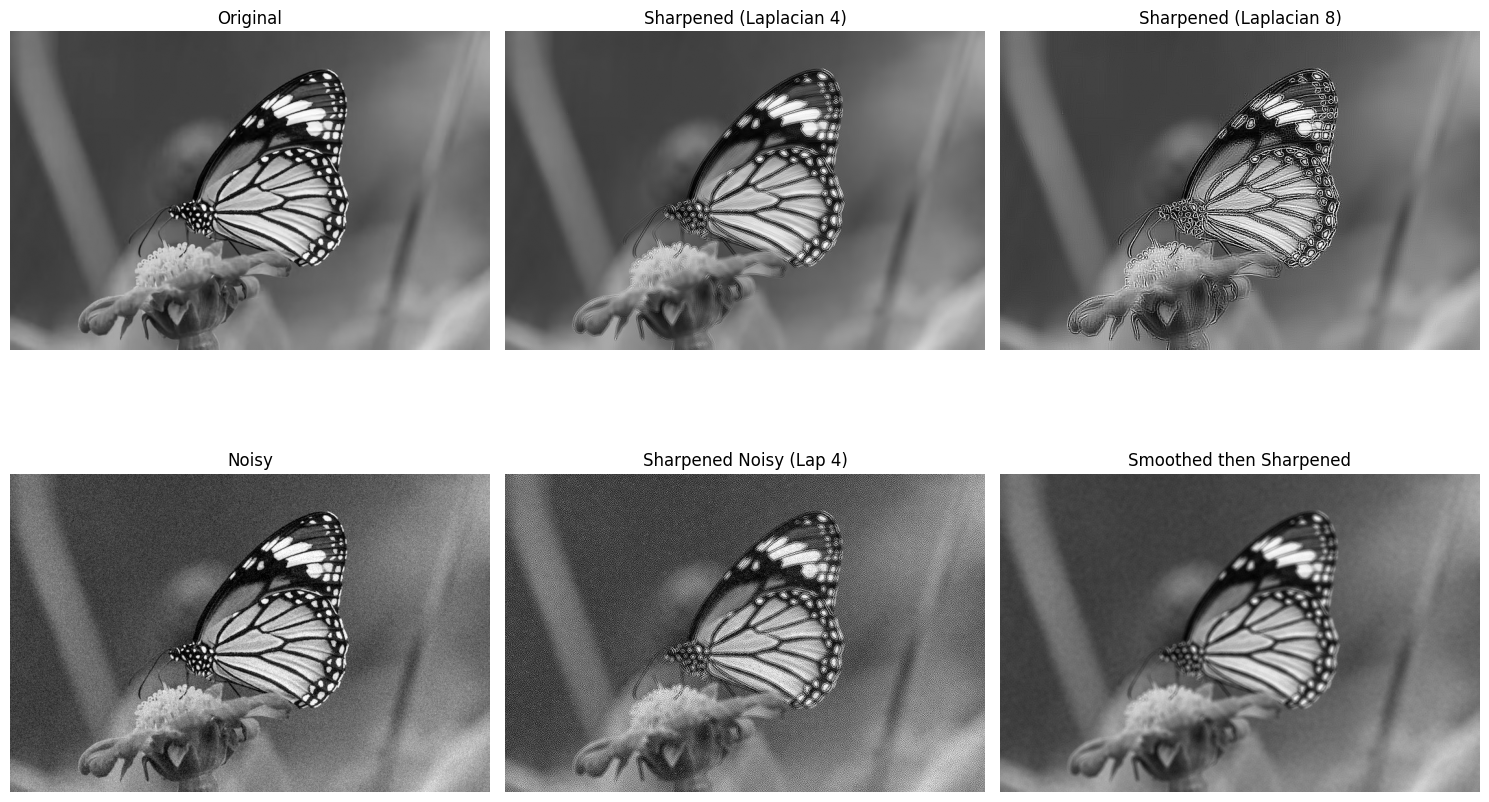

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(img, cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')
axes[0, 1].imshow(sharp_4, cmap='gray', vmin=0, vmax=1)
axes[0, 1].set_title('Sharpened (Laplacian 4)')
axes[0, 1].axis('off')
axes[0, 2].imshow(sharp_8, cmap='gray', vmin=0, vmax=1)
axes[0, 2].set_title('Sharpened (Laplacian 8)')
axes[0, 2].axis('off')
axes[1, 0].imshow(noisy, cmap='gray', vmin=0, vmax=1)
axes[1, 0].set_title('Noisy')
axes[1, 0].axis('off')
axes[1, 1].imshow(sharp_noisy_4, cmap='gray', vmin=0, vmax=1)
axes[1, 1].set_title('Sharpened Noisy (Lap 4)')
axes[1, 1].axis('off')
axes[1, 2].imshow(sharp_after_smooth, cmap='gray', vmin=0, vmax=1)
axes[1, 2].set_title('Smoothed then Sharpened')
axes[1, 2].axis('off')
plt.tight_layout()
plt.show()


- **The Plots:** Comparisons of the original and noisy images being sharpened using two different Laplacian kernels (`lap_4` without diagonals, and `lap_8` with diagonals).
- **The Explanation:** 
  - The Laplacian highlights regions of rapid intensity change (edges). Subtracting this from the image makes edges crisper. The 8-neighbor kernel gives a much stronger sharpening effect than the 4-neighbor one because it accounts for diagonal intensity changes.
  - **The Noisy Image Problem:** When applying the Laplacian directly to the noisy image, the noise is drastically amplified—the image looks terrible because noise is entirely made up of high-frequency changes.
  - **The Solution:** The last plot (Smoothed then Sharpened) shows that by applying a Gaussian blur *first* to dampen the noise, and *then* sharpening, you can recover edge detail without amplifying the noise.

# Experiment 3: Unsharp Masking

In [10]:
def unsharp_mask(image, sigma, k=1.0):
    blurred = gaussian_filter(image, sigma=sigma, mode='reflect')
    mask = image - blurred
    sharpened = image + k * mask
    return np.clip(sharpened, 0, 1), mask


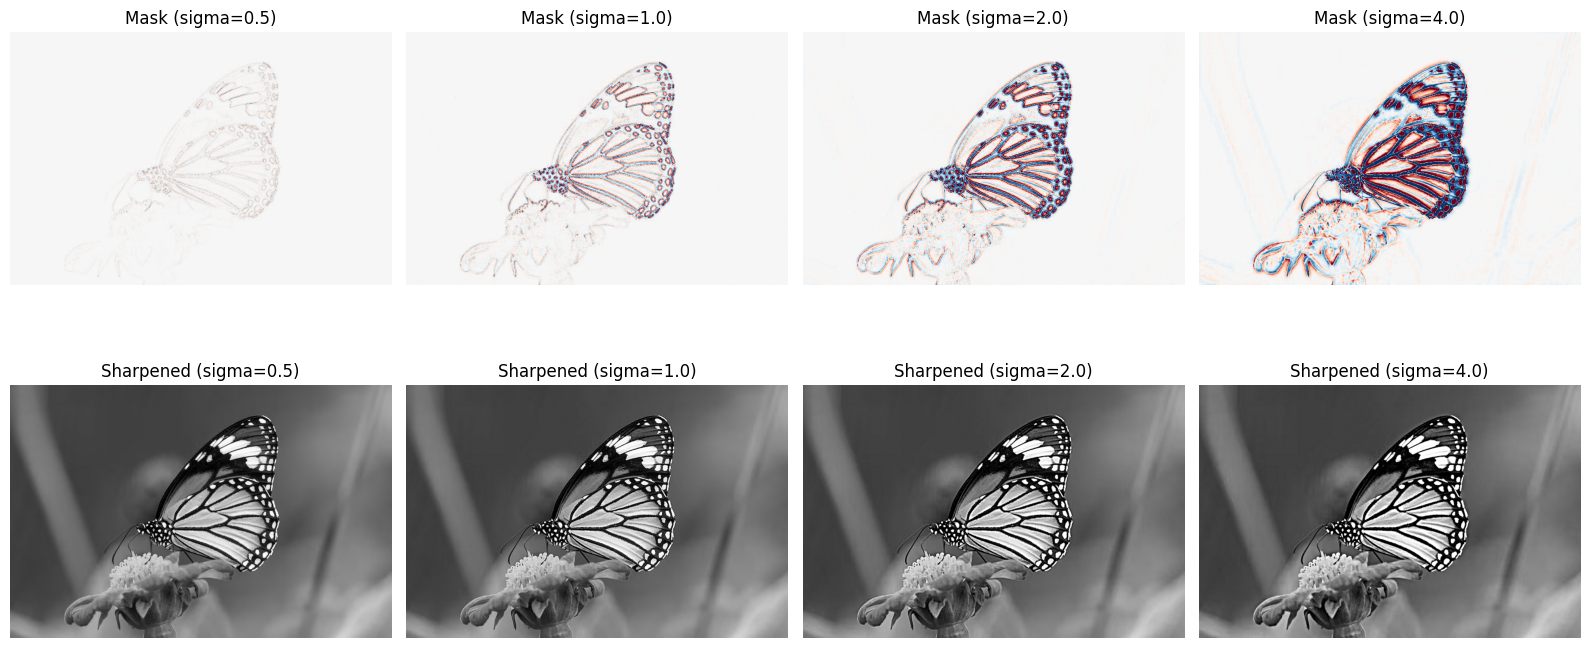

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sigmas_um = [0.5, 1.0, 2.0, 4.0]
for i, sigma in enumerate(sigmas_um):
    result, mask = unsharp_mask(img, sigma=sigma, k=1.0)
    axes[0, i].imshow(mask, cmap='RdBu_r', vmin=-0.2, vmax=0.2)
    axes[0, i].set_title(f'Mask (sigma={sigma})')
    axes[0, i].axis('off')
    axes[1, i].imshow(result, cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f'Sharpened (sigma={sigma})')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()


In [12]:
sigma_fixed = 1.0
for k in [0.5, 1.0, 2.0, 5.0]:
    result, mask = unsharp_mask(img, sigma=sigma_fixed, k=k)
    p = psnr(img, result, data_range=1.0)
    print(f'k={k} PSNR={p:.2f} dB')


k=0.5 PSNR=38.04 dB
k=1.0 PSNR=32.83 dB
k=2.0 PSNR=28.31 dB
k=5.0 PSNR=23.53 dB


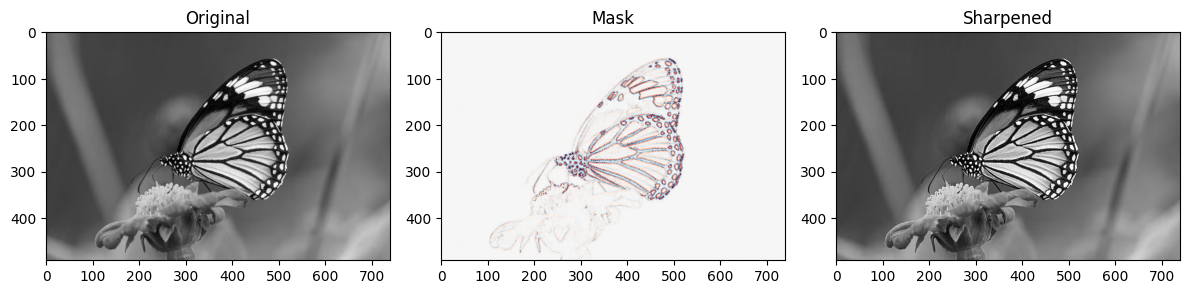

In [13]:
_, mask = unsharp_mask(img, sigma=1.0, k=1.0)
fig, axes = plt.subplots(1,3,figsize=(12,4))
axes[0].imshow(img,cmap='gray',vmin=0,vmax=1)
axes[0].set_title('Original')
axes[1].imshow(mask,cmap='RdBu_r',vmin=-0.2,vmax=0.2)
axes[1].set_title('Mask')
axes[2].imshow(img+mask,cmap='gray',vmin=0,vmax=1)
axes[2].set_title('Sharpened')
plt.tight_layout()
plt.show()


- **The Plots:** The isolated **Masks** (the detail signals) and the resulting **Sharpened** images across different values of $\sigma$. The masks are plotted with a red-blue colormap where flat regions are neutral, and edges show up as bright red/blue lines.
- **The Explanation:** 
  - Unsharp masking works by subtracting a blurred version of the image from the original to isolate the "edges". 
  - When $\sigma$ is small ($0.5$), the mask only captures very fine, tiny details. As $\sigma$ increases ($4.0$), the mask captures broader, thicker edge structures. 
  - By adding this mask back into the image (controlled by the multiplier $k$), you force the edges to become more pronounced, artificially making the image look crisper.

# Experiment 4: High-Boost Filtering

In [14]:
def high_boost_filter(image, sigma, A):
    blurred = gaussian_filter(image, sigma=sigma, mode='reflect')
    return np.clip(A*image - blurred, 0, 1)

sigma_hb = 1.5
boost_factors = [1.0, 1.5, 2.0, 3.0, 5.0]
results_hb = [high_boost_filter(img, sigma_hb, A) for A in boost_factors]


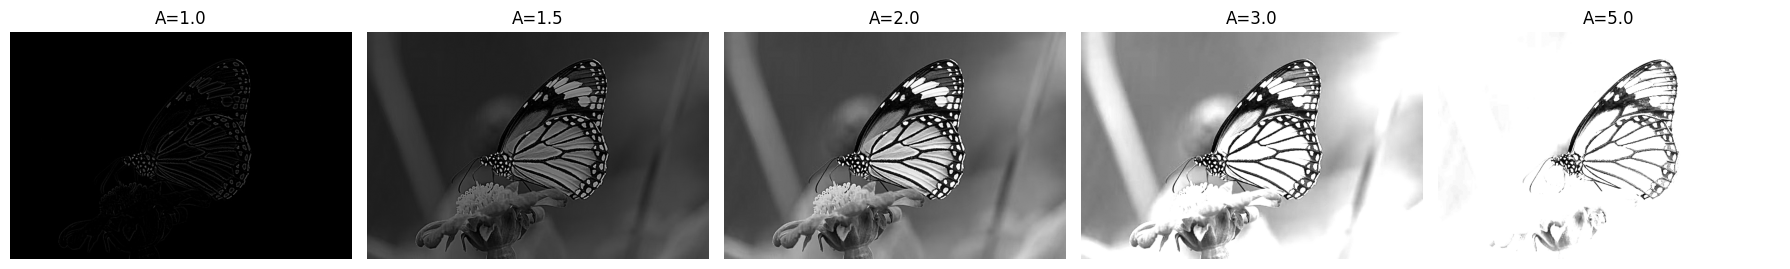

In [15]:
fig, axes = plt.subplots(1, len(boost_factors), figsize=(18,4))
for ax, A, r in zip(axes, boost_factors, results_hb):
    ax.imshow(r, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'A={A}')
    ax.axis('off')
plt.tight_layout()
plt.show()


- **The Plots:** A side-by-side comparison of the image processed with a high-boost filter across varying boost factors ($A = 1.0$ up to $5.0$).
- **The Explanation:** 
  - High-boost filtering is a generalization of unsharp masking. Instead of just adding the edge mask back, it scales the entire original image by $A$ before subtracting the blurred version. 
  - When $A = 1$, it behaves exactly like unsharp masking. But as $A$ increases beyond 1 (e.g., 3.0 or 5.0), the image becomes increasingly brighter and highly contrasted. It emphasizes the high-frequency edge details heavily while also retaining and boosting the low-frequency base of the image.